In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [8]:
df.shape

(27, 2)

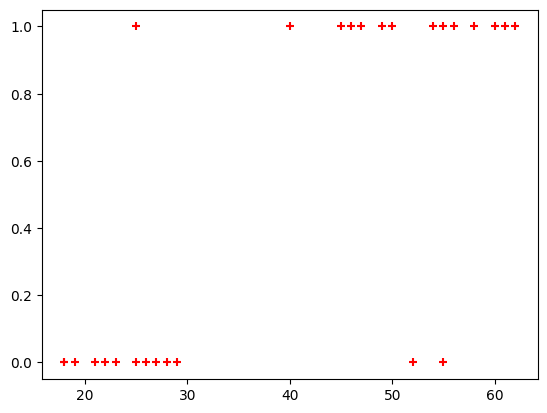

In [11]:
plt.scatter(df.age,df.bought_insurance,color = 'red',marker = '+')

In [41]:
x = df[['age']]
y = df['bought_insurance']

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size = 0.8,random_state = 42)
X_test

,age
8,62
13,29
9,61
21,26
0,22
11,28


In [43]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [44]:
model.fit(X_train,y_train)

LogisticRegression()

In [45]:
model.coef_

array([[0.11307708]])

In [46]:
model.intercept_

array([-4.15311919])

In [48]:
y_predict = model.predict(X_test)
y_predict

array([1, 0, 1, 0, 0, 0], dtype=int64)

In [72]:
df['probs'] = model.predict_proba(df[['age']])[:,1]

In [73]:
df

,age,bought_insurance,probs
0,22,0,0.159035
1,25,0,0.209790
2,47,1,0.761606
3,52,0,0.849014
4,46,1,0.740473
5,56,1,0.898366
6,55,0,0.887566
7,60,1,0.932862
8,62,1,0.945713
9,61,1,0.939607


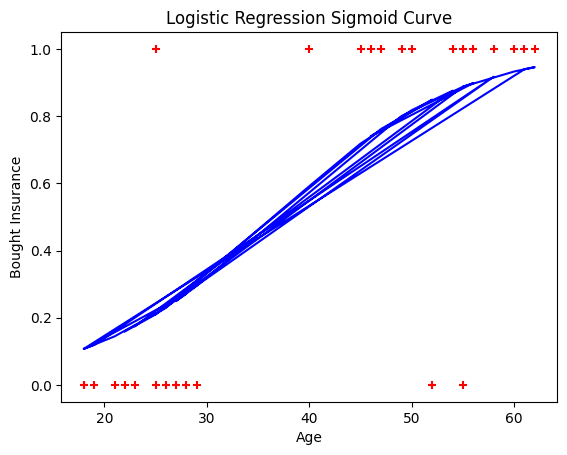

In [74]:
plt.scatter(df.age,df.bought_insurance,color = 'red',marker = '+')
plt.plot(df['age'],df['probs'],color = 'blue')
plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.title("Logistic Regression Sigmoid Curve")
plt.show()

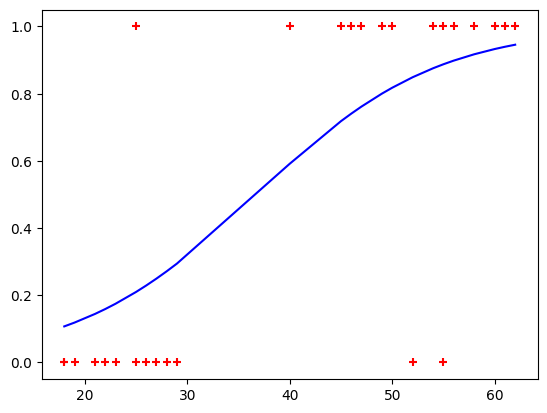

In [75]:
df_sorted = df.sort_values('age')
plt.scatter(df['age'],df['bought_insurance'],color = 'red',marker = '+')
plt.plot(df_sorted['age'],df_sorted['probs'],color = 'blue')
plt.show()

In [76]:
import math
def sigmoid(x):
    return 1 /(1+math.exp(-x))

In [77]:
def prediction_function(age):
    z = 0.112 * age + (-4.20)
    y = sigmoid(z)
    return y

In [78]:
age = 35
prediction_function(age)

0.43045377606077095

In [79]:
age = 40
prediction_function(age)

0.569546223939229

In [80]:
age = 37.5
prediction_function(age)

0.5

In [81]:
age = 82
prediction_function(age)

0.9931999362344026

In [82]:
age = 66
prediction_function(age)

0.9605321106735979

In [83]:
age = 77
prediction_function(age)

0.9881557756401541

In [84]:
age = 13
prediction_function(age)

0.0604264033944818

In [85]:
age = 58
prediction_function(age)

0.9085452184644403

In [88]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X)
accuracy = accuracy_score(y,y_pred)
print("Accuracy: ",accuracy)

Accuracy:  0.8888888888888888


In [89]:
#exercise 1

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [94]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [96]:
salary_retention = pd.crosstab(df.salary, df.left)
salary_retention 

left,0,1
salary,,
high,1155,82
low,5144,2172
medium,5129,1317


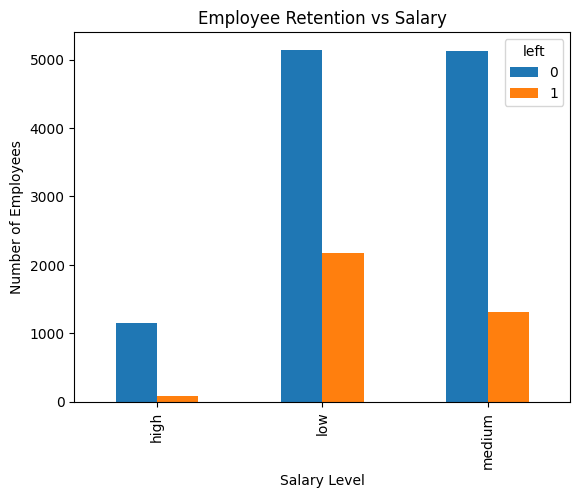

In [97]:
salary_retention.plot(kind='bar')
plt.title("Employee Retention vs Salary")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()


In [98]:
dept_retention = pd.crosstab(df.Department, df.left)
dept_retention

left,0,1
Department,,
IT,954,273
RandD,666,121
accounting,563,204
hr,524,215
management,539,91
marketing,655,203
product_mng,704,198
sales,3126,1014
support,1674,555


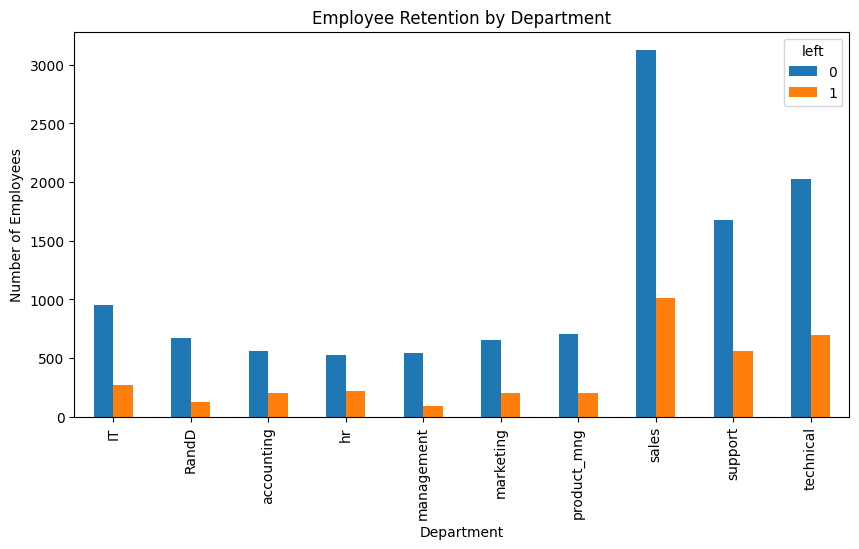

In [99]:
dept_retention.plot(kind='bar', figsize=(10,5))
plt.title("Employee Retention by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

In [100]:
X = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
y = df['left']

In [102]:
le = LabelEncoder()
X['salary'] = le.fit_transform(X['salary'])

C:\Users\sumai\AppData\Local\Temp\ipykernel_3308\3179573618.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['salary'] = le.fit_transform(X['salary'])


In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [104]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [105]:
y_pred = model.predict(X_test)

In [106]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7583333333333333


In [108]:
#exercise 2

In [109]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [110]:
iris = load_iris()

In [111]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [112]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [113]:
X = iris.data
y = iris.target

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [117]:
y_pred = model.predict(X_test)

In [118]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [119]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [121]:
sample = [[5.1, 3.5, 1.4, 0.2]]  # Example flower
prediction = model.predict(sample)

In [122]:
print("Predicted Class:", prediction)
print("Flower Name:", iris.target_names[prediction][0])

Predicted Class: [0]
Flower Name: setosa
